In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:

df=pd.read_csv("/Users/deepankjuneja/Desktop/datascienceproject/eda_data.csv")

In [3]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'hourly', 'employer_provided', 'min_salary', 'max_salary', 'avg_salary',
       'company_txt', 'job_state', 'same_state', 'age', 'python_yn', 'r_yn',
       'spark', 'aws', 'excel', 'job_simp', 'seniority', 'desc_length',
       'num_comp'],
      dtype='object')

In [4]:
df_model=df[['avg_salary','Rating','Size','Type of ownership','Industry','Sector','Revenue'
    ,'num_comp','hourly','employer_provided','job_state','age','python_yn','spark','aws'
    ,'excel','job_simp','seniority','desc_length']]
df_model

,avg_salary,Rating,Size,Type of ownership,Industry,Sector,Revenue,num_comp,hourly,employer_provided,job_state,age,python_yn,spark,aws,excel,job_simp,seniority,desc_length
0,72.0,3.8,501 to 1000 employees,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),0,0,0,NM,47,1,0,0,1,data scientist,na,2536
1,87.5,3.4,10000+ employees,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),0,0,0,MD,36,1,0,0,0,data scientist,na,4783
2,85.0,4.8,501 to 1000 employees,Company - Private,Security Services,Business Services,$100 to $500 million (USD),0,0,0,FL,10,1,1,0,1,data scientist,na,3461
3,76.5,3.8,1001 to 5000 employees,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),3,0,0,WA,55,1,0,0,0,data scientist,na,3883
4,114.5,2.9,51 to 200 employees,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,3,0,0,NY,22,1,0,0,1,data scientist,na,2728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,84.5,3.9,10000+ employees,Company - Public,Biotech & Pharmaceuticals,Biotech & Pharmaceuticals,$10+ billion (USD),3,0,0,MA,190,0,0,1,0,other,senior,6162
738,102.5,4.4,1001 to 5000 employees,Company - Public,Internet,Information Technology,$100 to $500 million (USD),3,0,0,TN,14,1,1,1,0,data engineer,senior,6130
739,73.5,2.6,501 to 1000 employees,College / University,Colleges & Universities,Education,Unknown / Non-Applicable,0,0,0,PA,36,0,0,0,1,other,na,3078
740,127.5,3.2,1 to 50 employees,Company - Private,Staffing & Outsourcing,Business Services,$5 to $10 million (USD),0,0,0,PA,-1,0,0,0,1,manager,na,1642


In [5]:
# get dumy data
df_dum=pd.get_dummies(df_model)
df_dum

,avg_salary,Rating,num_comp,hourly,employer_provided,age,python_yn,spark,aws,excel,...,job_simp_data scientist,job_simp_director,job_simp_machine learning engineer,job_simp_manager,job_simp_other,seniority_junior,seniority_lead,seniority_na,seniority_principal,seniority_senior
0,72.0,3.8,0,0,0,47,1,0,0,1,...,True,False,False,False,False,False,False,True,False,False
1,87.5,3.4,0,0,0,36,1,0,0,0,...,True,False,False,False,False,False,False,True,False,False
2,85.0,4.8,0,0,0,10,1,1,0,1,...,True,False,False,False,False,False,False,True,False,False
3,76.5,3.8,3,0,0,55,1,0,0,0,...,True,False,False,False,False,False,False,True,False,False
4,114.5,2.9,3,0,0,22,1,0,0,1,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737,84.5,3.9,3,0,0,190,0,0,1,0,...,False,False,False,False,True,False,False,False,False,True
738,102.5,4.4,3,0,0,14,1,1,1,0,...,False,False,False,False,False,False,False,False,False,True
739,73.5,2.6,0,0,0,36,0,0,0,1,...,False,False,False,False,True,False,False,True,False,False
740,127.5,3.2,0,0,0,-1,0,0,0,1,...,False,False,False,True,False,False,False,True,False,False


In [6]:
# train test split
from sklearn.model_selection import train_test_split
x=df_dum.drop('avg_salary',axis=1)
y=df_dum.avg_salary.values


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [7]:
# multiple linear regression
import statsmodels.api as sm
x = x.astype(int)
x_sm=x= sm.add_constant(x)
model = sm.OLS(y,x_sm)
model.fit().summary() 


from sklearn.linear_model import LinearRegression,Lasso
from sklearn.model_selection import cross_val_score

lm=LinearRegression()
lm.fit(x_train,y_train)

np.mean(cross_val_score(lm,x_train,y_train,scoring='neg_mean_absolute_error',cv=3))

np.float64(-20.571483469384933)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.488e+01, tolerance: 6.059e+01
  model = cd_fast.enet_coordinate_descent(


,alpha,error
7,0.8,-19.242673


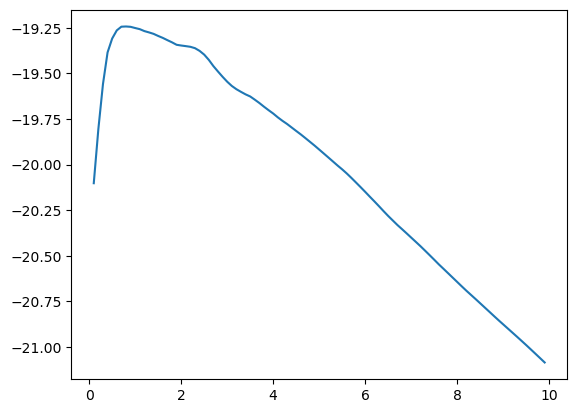

In [8]:
# lasso regression
lm_l=Lasso(alpha=.13)
lm_l.fit(x_train,y_train)
np.mean(cross_val_score(lm_l,x_train,y_train,scoring='neg_mean_absolute_error',cv=3))
alpha=[]
error=[]
for i in range(1,100):
    alpha.append(i/10)
    lml=Lasso(alpha=(i/100))
    error.append(np.mean(cross_val_score(lml,x_train,y_train,scoring='neg_mean_absolute_error',cv=3)))

plt.plot(alpha,error)
err=tuple(zip(alpha,error))

df_err=pd.DataFrame(err,columns=['alpha','error'])
df_err[df_err.error==max(df_err.error)]

In [9]:
# random forest
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
np.mean(cross_val_score(rf,x_train,y_train,scoring='neg_mean_absolute_error',cv=3 ))

np.float64(-15.126044967440905)

In [10]:
# tune model gridsearchcv
from sklearn.model_selection import GridSearchCV
parameters = {'n_estimators':range(10,300,10),'criterion': ['squared_error', 'absolute_error'],'max_features': ['sqrt', 'log2']}

gs=GridSearchCV (rf,parameters,scoring='neg_mean_absolute_error',cv=3)
gs.fit(x_train,y_train)


,estimator,RandomForestRegressor()
,param_grid,"{'criterion': ['squared_error', 'absolute_error'], 'max_features': ['sqrt', 'log2'], 'n_estimators': range(10, 300, 10)}"
,scoring,'neg_mean_absolute_error'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,60


In [11]:
gs.best_score_

np.float64(-15.290724432708359)

In [12]:
gs.best_estimator_

,n_estimators,60
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# test esembles
tpred_lm=lm.predict(x_test) 
tpred_lml=lm_l.predict(x_test)
tpred_rf=gs.best_estimator_.predict(x_test)

from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test,tpred_lm)
mean_absolute_error(y_test,tpred_lml)
mean_absolute_error(y_test,tpred_rf)

mean_absolute_error(y_test,(tpred_lm+tpred_rf)/2)

14.626697711652017

In [14]:
mean_absolute_error(y_test,tpred_lm)

19.26656139018624

In [15]:
mean_absolute_error(y_test,tpred_lml)

19.75865447857923

In [16]:
mean_absolute_error(y_test,tpred_rf)

12.347091722595078

In [23]:
# import pickle
# pickl = {'model': gs.best_estimator_}
# pickle.dump( pickl, open( 'model_file' + ".p", "wb" ) )

# file_name = "model_file.p"
# with open(file_name, 'rb') as pickled:
#     data = pickle.load(pickled)
#     model = data['model']

# model.predict(np.array(list(x_test.iloc[1,:])).reshape(1,-1))[0]

# list(x_test.iloc[1,:])

In [25]:
import pickle

pickl = {
    "model": gs.best_estimator_,
    "model_columns": x_train.columns.tolist()
}

with open("model_file.p", "wb") as file:
    pickle.dump(pickl, file)

In [26]:
with open("model_file.p", "rb") as file:
    data = pickle.load(file)

print(data.keys())

dict_keys(['model', 'model_columns'])


In [24]:
df_dum.drop("avg_salary", axis=1).columns

Index(['Rating', 'num_comp', 'hourly', 'employer_provided', 'age', 'python_yn',
       'spark', 'aws', 'excel', 'desc_length',
       ...
       'job_simp_data scientist', 'job_simp_director',
       'job_simp_machine learning engineer', 'job_simp_manager',
       'job_simp_other', 'seniority_junior', 'seniority_lead', 'seniority_na',
       'seniority_principal', 'seniority_senior'],
      dtype='object', length=178)

In [21]:
df_dum.drop("avg_salary", axis=1).columns.tolist()

['Rating',
 'num_comp',
 'hourly',
 'employer_provided',
 'age',
 'python_yn',
 'spark',
 'aws',
 'excel',
 'desc_length',
 'Size_-1',
 'Size_1 to 50 employees',
 'Size_10000+ employees',
 'Size_1001 to 5000 employees',
 'Size_201 to 500 employees',
 'Size_5001 to 10000 employees',
 'Size_501 to 1000 employees',
 'Size_51 to 200 employees',
 'Size_Unknown',
 'Type of ownership_-1',
 'Type of ownership_College / University',
 'Type of ownership_Company - Private',
 'Type of ownership_Company - Public',
 'Type of ownership_Government',
 'Type of ownership_Hospital',
 'Type of ownership_Nonprofit Organization',
 'Type of ownership_Other Organization',
 'Type of ownership_School / School District',
 'Type of ownership_Subsidiary or Business Segment',
 'Type of ownership_Unknown',
 'Industry_-1',
 'Industry_Accounting',
 'Industry_Advertising & Marketing',
 'Industry_Aerospace & Defense',
 'Industry_Architectural & Engineering Services',
 'Industry_Auctions & Galleries',
 'Industry_Banks & 